# EDA
In this notebook, we are going to perform EDA (Univariate and Multivariate)

**But first we have to create some features**

- PassengerId --> 2 Features: Group No & Passenger No
- Cabin --> 3 Features: Deck, Num & Side
- TotalBill --> Sum of RoomService, FoodCourt, ShoppingMall, Spa, VRDeck|

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')

In [3]:
# PassengerId

In [4]:
train['Groupno'] = train['PassengerId'].str.split('_').str.get(0)
train['Passengerno'] = train['PassengerId'].str.split('_').str.get(1)

In [5]:
# Cabin

In [6]:
train['Deck'] =  train['Cabin'].str.split('/').str.get(0)
train['Num'] =  train['Cabin'].str.split('/').str.get(1)
train['Side'] =  train['Cabin'].str.split('/').str.get(2)

In [7]:
# Total Bill

In [8]:
train['TotalBill'] =  train[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)

In [9]:
# Droppping the original columns 
train.drop(columns=['PassengerId','Cabin'],inplace=True)

In [10]:
train.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Groupno,Passengerno,Deck,Num,Side,TotalBill
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,01,B,0,P,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,01,F,0,S,736.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,01,A,0,S,10383.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,02,A,0,S,5176.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,0004,01,F,1,S,1091.0


## Univariate Analysis

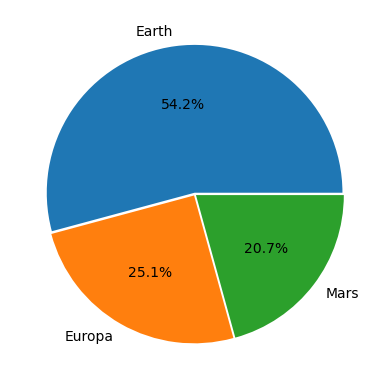

In [11]:
plt.pie(train['HomePlanet'].value_counts(),labels=train['HomePlanet'].value_counts().index,autopct='%0.1f%%',explode = [0.01,0.01,0.01]);

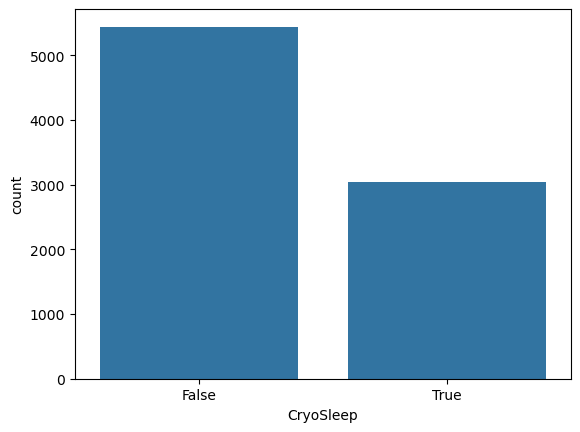

In [12]:
# CryoSleep
sns.barplot(train['CryoSleep'].value_counts());

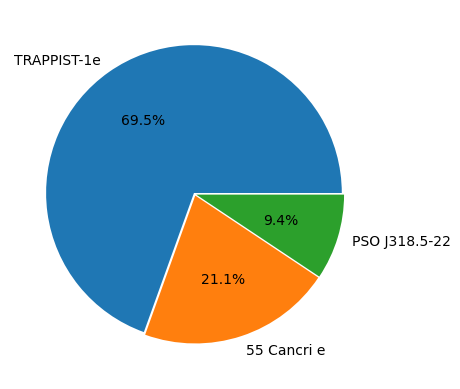

In [13]:
# Destination
plt.pie(train['Destination'].value_counts(),labels=train['Destination'].value_counts().index,autopct='%0.1f%%',explode = [0.01,0.01,0.01]);

<Axes: xlabel='Age', ylabel='Count'>

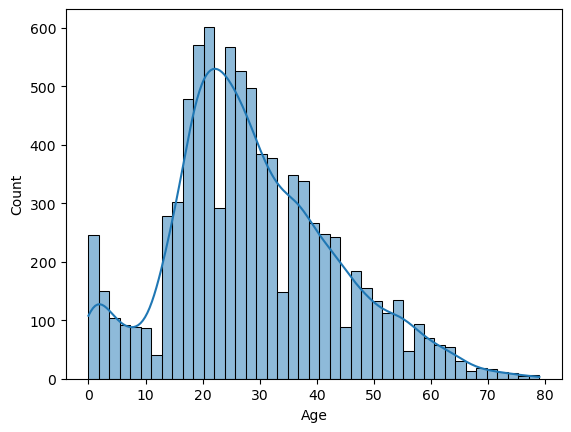

In [14]:
# Age
sns.histplot(train['Age'],kde=True)

In [15]:
# Data of new born babies
train[train['Age']==0].shape[0]

178

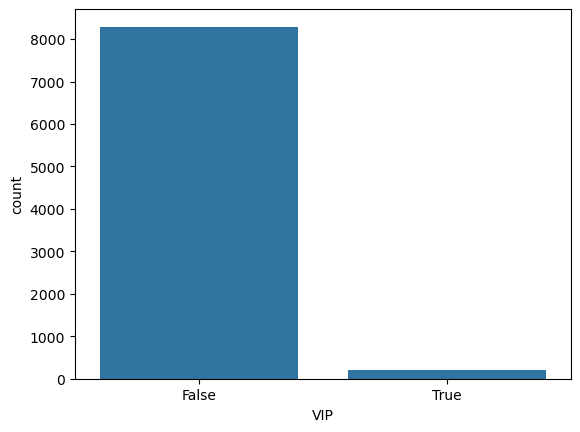

In [16]:
# Vip
sns.barplot(train['VIP'].value_counts());

<Axes: xlabel='TotalBill', ylabel='Count'>

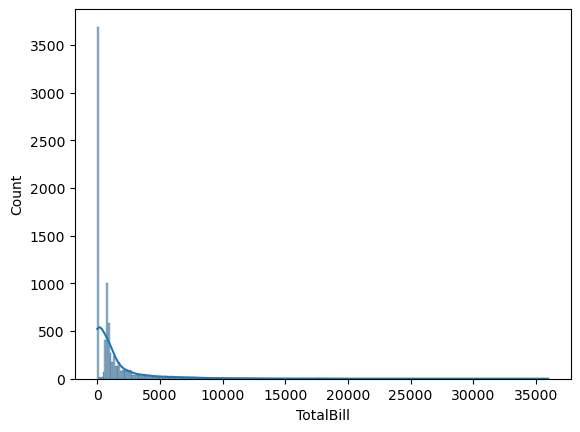

In [17]:
# TotalBill
sns.histplot(train['TotalBill'],kde=True)

<Axes: xlabel='Passengerno', ylabel='count'>

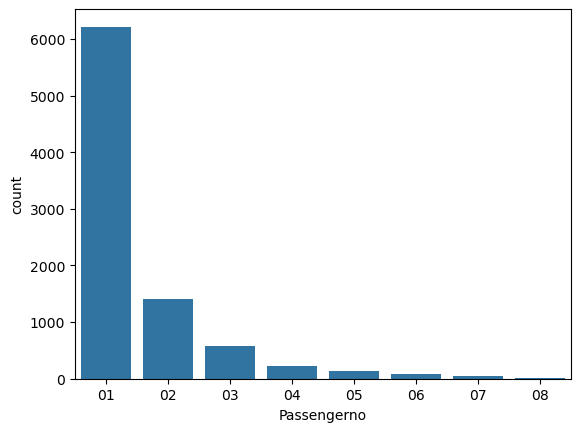

In [18]:
# Passengerno
sns.barplot(train['Passengerno'].value_counts())

<Axes: xlabel='Deck', ylabel='count'>

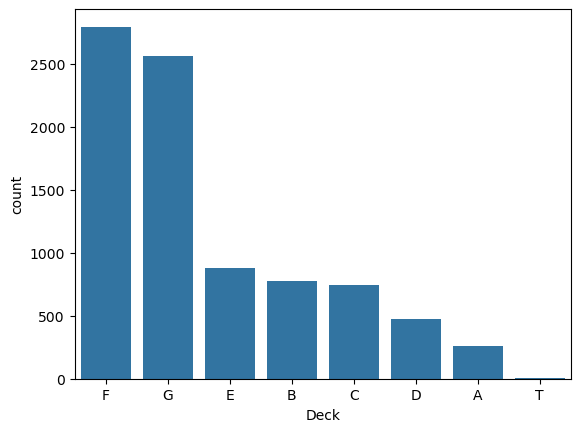

In [19]:
# Deck
sns.barplot(train['Deck'].value_counts())

In [20]:
# Converting the data type of Num to int
train['Num'] = train['Num'].astype(np.float64)

<Axes: xlabel='Num', ylabel='Count'>

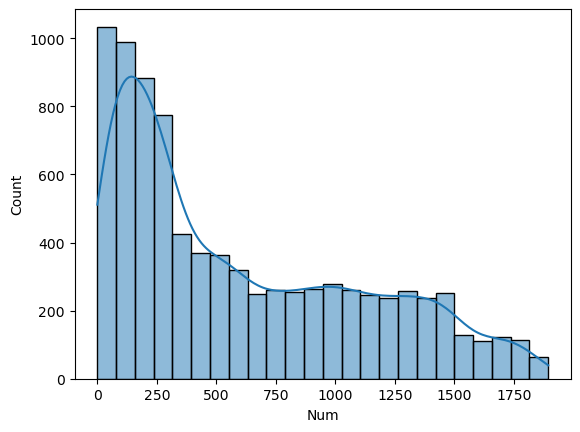

In [21]:
sns.histplot(train['Num'],kde=True)

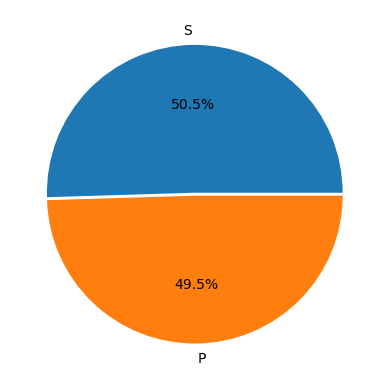

In [22]:
# Side
plt.pie(train['Side'].value_counts(),labels=train['Side'].value_counts().index,autopct='%0.1f%%',explode = [0.01,0.01]);

<Axes: xlabel='Transported', ylabel='count'>

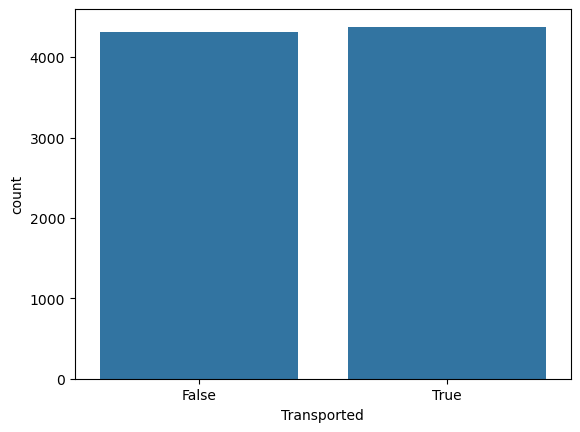

In [23]:
sns.barplot(train['Transported'].value_counts())

### Some Conclusions
- In the 'Age' column, there is a spike in the data where ages are below 10. It seems that there are new born babies also.
- Majority of the people are from 15 yrs old to 35/40 yrs old.
- Very few of the passengers are VIP.
- Most passengers are staying in deck F and G.
- There are outliers in the column TotalBill.
- The dataset is balanced.

## Multivariate Analysis

In [24]:
train.head(2)

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Groupno,Passengerno,Deck,Num,Side,TotalBill
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,0001,01,B,0.0,P,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,0002,01,F,0.0,S,736.0


<Axes: xlabel='Num', ylabel='Count'>

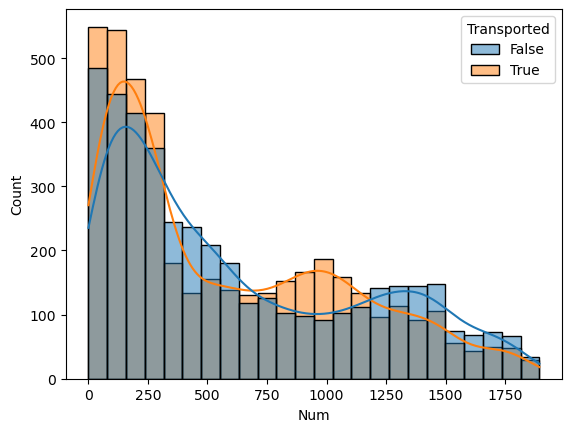

In [38]:
# Num with Transported
sns.histplot(data=train,x='Num',kde=True,hue='Transported')

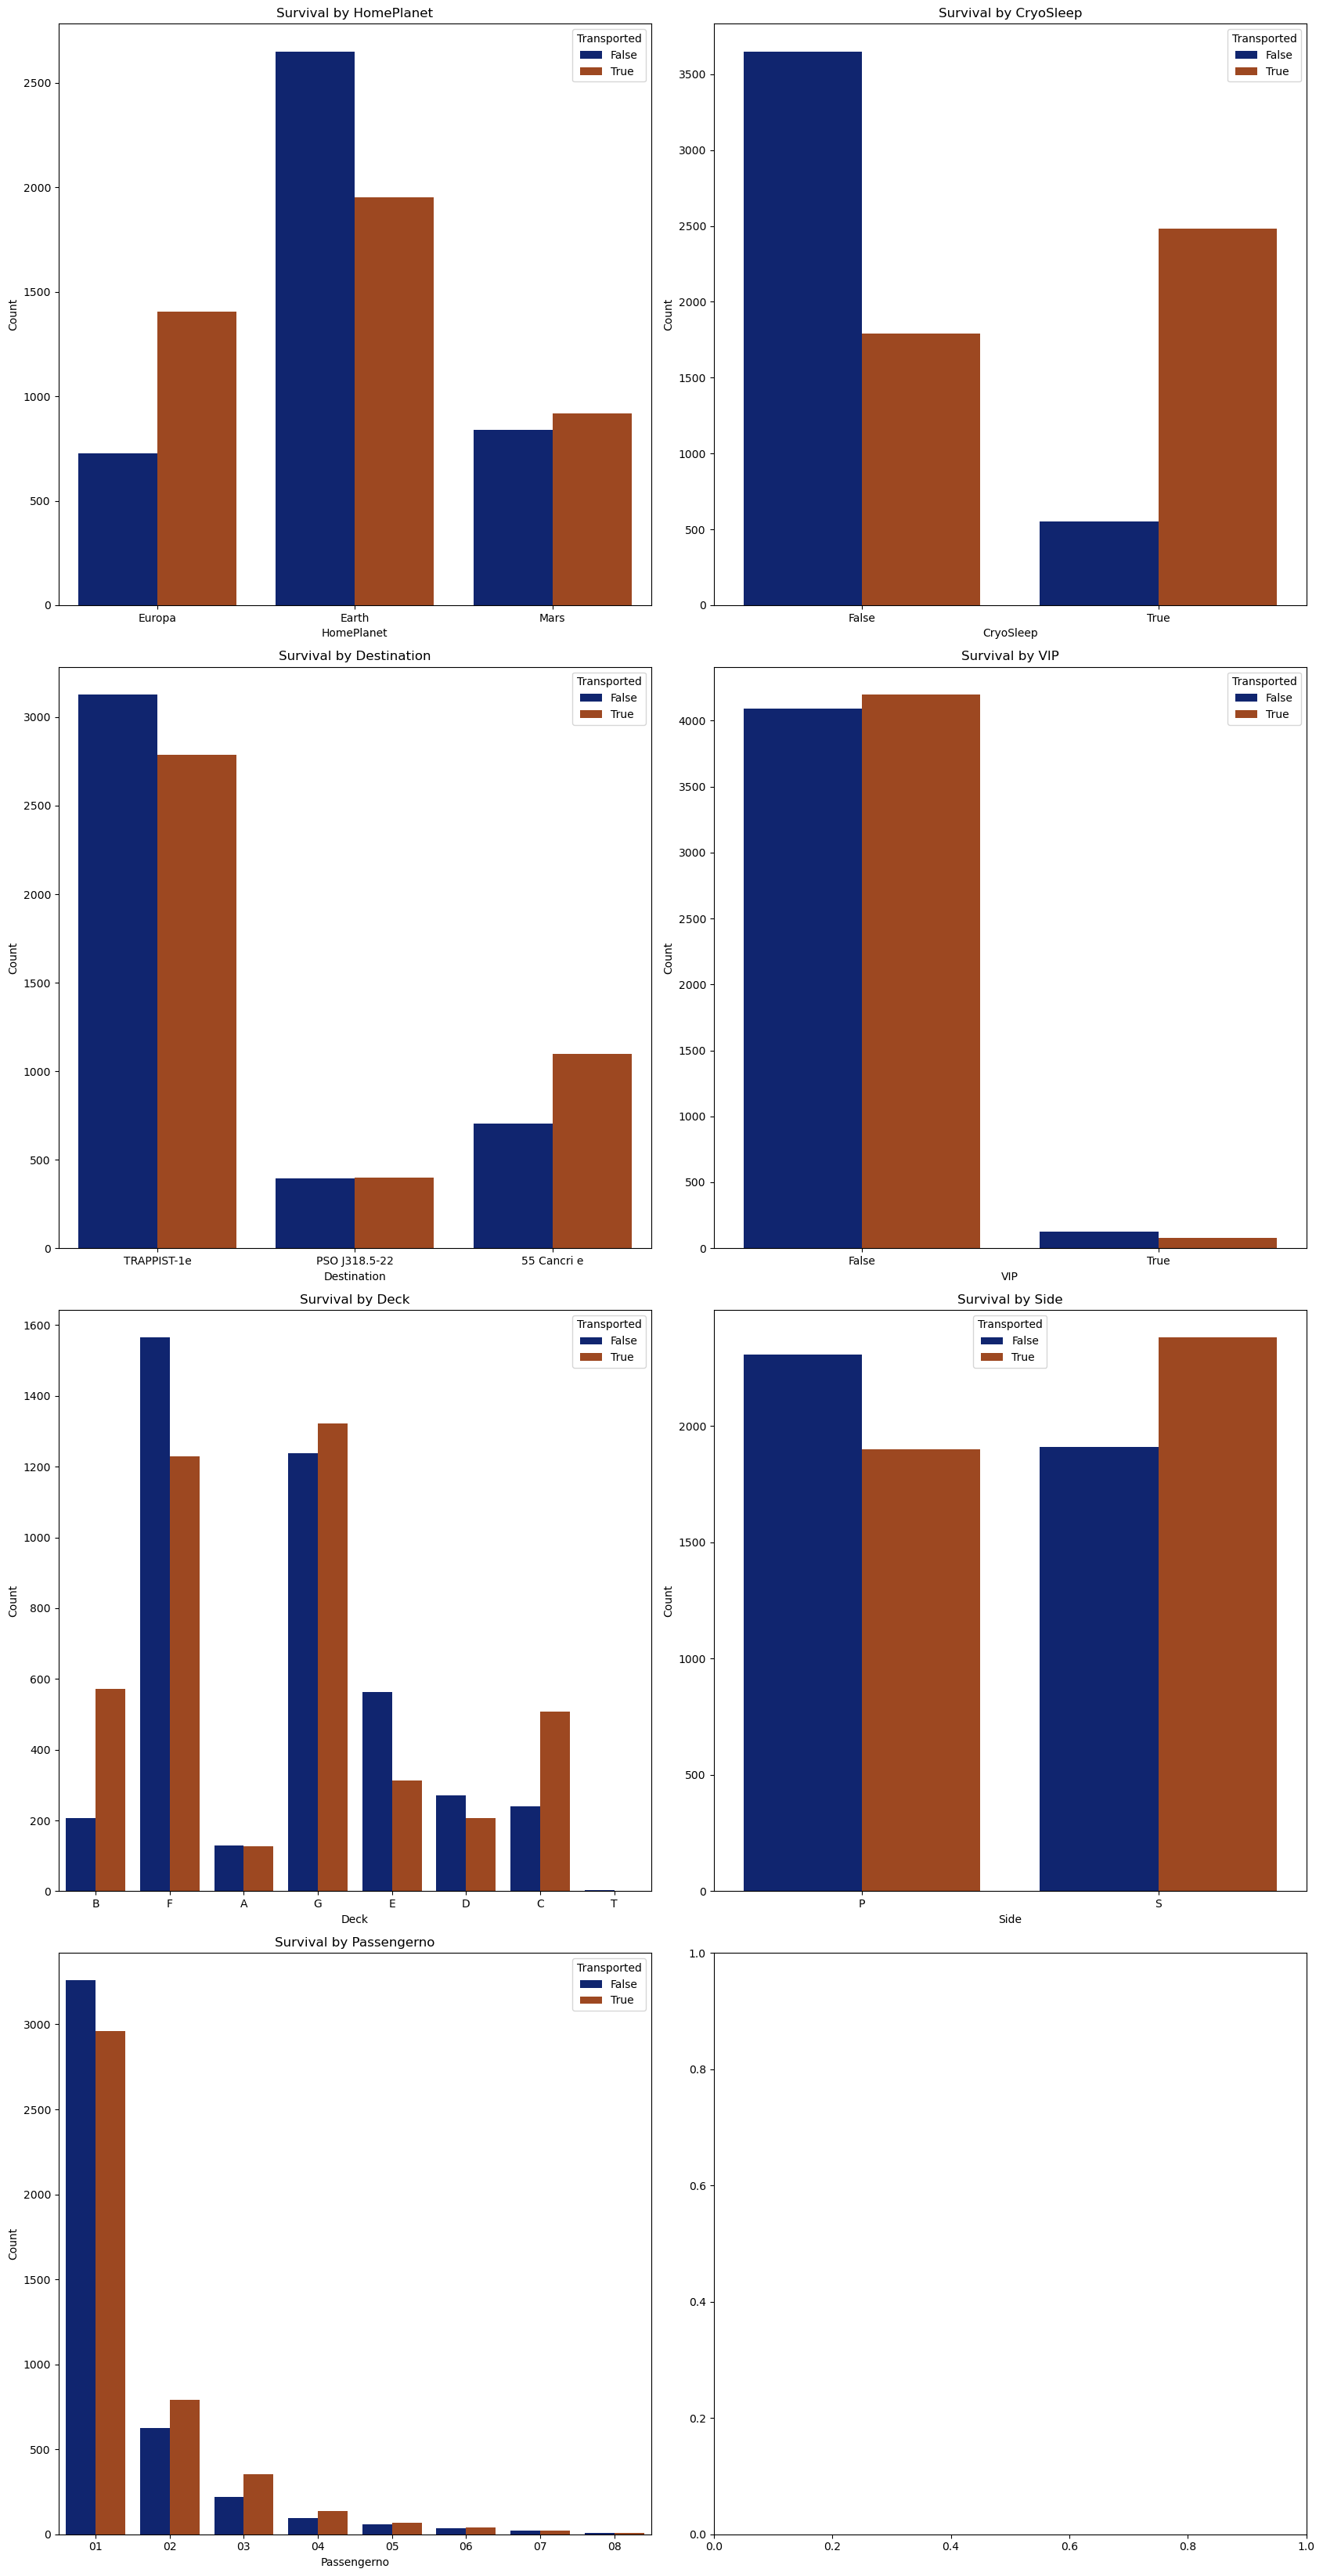

In [49]:

categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP','Deck','Side','Passengerno']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(17, 33))

axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    sns.countplot(
        x=train[col], 
        hue=train['Transported'], 
        palette='dark', 
        ax=axes[idx]  
    )
    axes[idx].set_title(f'Survival by {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Some Conclusions
- If your HomePlanet is Earth, then your chances of being transported to another dimension is less than the others.
- CryoSleep has an inverse relations with the target feature.
- Passengers going towards '55 Cancer e' has higher chances of being to another dimension.
- Passengers with 'P' side has lesser chances while the 'S' side has higher chances.
- Passengers with Passengerno 2 and onwards have higher chances to another dimension, while the one with the value=1 has lower chances to another dimension.

<Axes: xlabel='Age', ylabel='Count'>

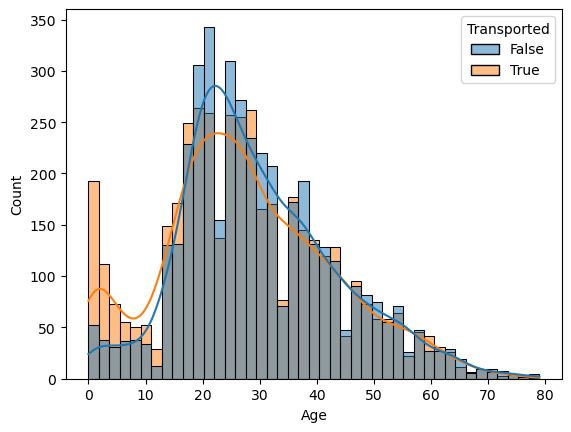

In [50]:
# Age with Transported
sns.histplot(data=train,x='Age',kde=True,hue='Transported')

<Axes: xlabel='TotalBill', ylabel='Count'>

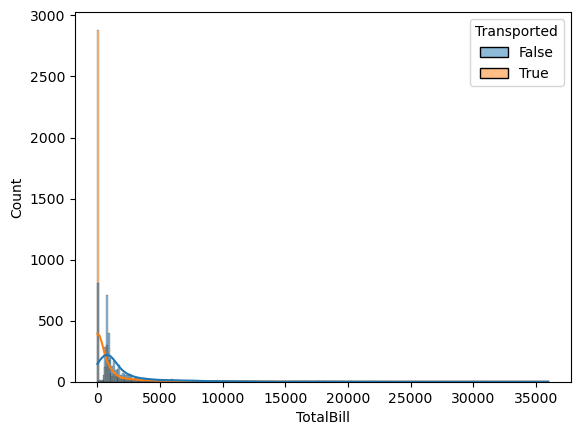

In [51]:
# Total Bill with Transported
sns.histplot(data=train,x='TotalBill',kde=True,hue='Transported')

<Axes: ylabel='TotalBill'>

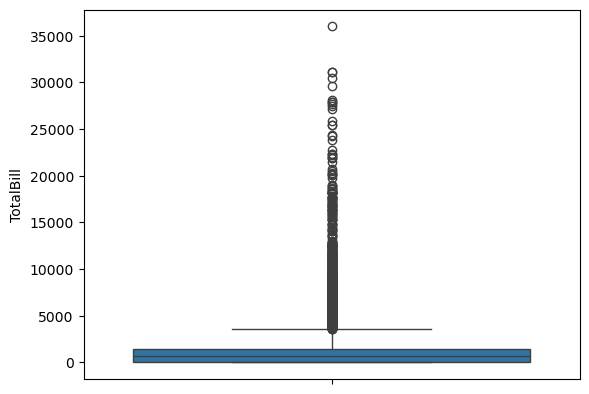

In [54]:
sns.boxplot(train['TotalBill'])

In [53]:
# RoomService, FoodCourt, ShoppingMall, Spa, VRDeck
train[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,224.687617,458.077203,173.729169,311.138778,304.854791
std,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,47.000000,76.000000,27.000000,59.000000,46.000000
max,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


### Some Conclusions
- Passengers with below the age of 18 has higher chance of being transported to another dimension.
- The columns used to make the TotalBill have very high no of outliers. And their std is also very high.

In [69]:
# Name
train['Name'].str.split(' ').str.get(1).nunique()

2217

In [70]:
train['Name'].str.split(' ').str.get(1)

0         Ofracculy
1             Vines
2            Susent
3            Susent
4       Santantines
           ...     
8688      Noxnuther
8689      Mondalley
8690         Connon
8691      Hontichre
8692      Hontichre
Name: Name, Length: 8693, dtype: object

In [73]:
train['Name'].head()

0      Maham Ofracculy
1         Juanna Vines
2        Altark Susent
3         Solam Susent
4    Willy Santantines
Name: Name, dtype: object

In [80]:
train[train['Name'].str.split(' ').str.get(1) == 'Susent']

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Groupno,Passengerno,Deck,Num,Side,TotalBill
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,0003,01,A,0.0,S,10383.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,0003,02,A,0.0,S,5176.0
3885,Europa,True,TRAPPIST-1e,47.0,False,0.0,0.0,0.0,0.0,0.0,Avijava Susent,True,4169,01,D,140.0,P,0.0
3886,Europa,False,TRAPPIST-1e,41.0,False,0.0,1562.0,0.0,2.0,16.0,Acruxon Susent,True,4169,02,D,140.0,P,1580.0
5954,Europa,False,TRAPPIST-1e,28.0,False,0.0,NaN,0.0,6.0,9837.0,Chelik Susent,False,6315,01,C,234.0,S,9843.0
7873,Europa,True,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Ariton Susent,True,8401,01,C,315.0,S,0.0


*Name column doesn't seem useful for now*

## Important Notes
- There is so much we can do with the dataset. But I will leave it here for now. Because the main focus of this project is to practice the MLOPs technique.

### What else can be done
- Try to find out relationships of features between them. This could help in filling missing values.
- Some creative way to extract information from Name column.